# 🐶 End-to-end Multi-class Dog breed Classification

This notebook builds an end-to-end multi-class image classifier using Tensorflow and TensorFlow Hub.

### 1. Problem

Identifying the breed of a dog given an image of a dog.

When I'm sitting at the cafe and I take a photo of a dog, I want to know what breed of dog it is.

### 2. Data

The data we're using is from Kaggle's dog breed identification competition.

https://www.kaggle.com/competitions/dog-breed-identification/data

### 3. Evaluation

The evaluation is a file with prediction probabilities for each dog breed of each test image.

https://www.kaggle.com/competitions/dog-breed-identification/overview/evaluation

### 4. Features

Some information about the data:
* We're dealing with images (unstructured data) so it's probably best we use deep learning/transfer learning.
* There are 120 breeds of dogs (this means there are 120 different classes).
* There are around 10,000+ images in the training set
* There are around 10,000+ images in the test set




### Get Our workspace ready

* Import TensorFlow 2.x
* Import TensorFlow Hub
* Make sure we're using a GPU

In [ ]:
# Import TensorFlow into colab
import tensorflow as tf
print("TF Version:", tf.__version__)

TF Version: 2.20.0


In [ ]:
# Import necessary tools
import tensorflow_hub as hub
print("TF_Hub:", hub.__version__)

# Check GPU Availability
print("GPU", "available" if tf.config.list_physical_devices("GPU") else "not available :/")

TF_Hub: 0.16.1
GPU available


  ## Getting our data ready (turning it inot tensors)

 With all machine learning models, our data has to be in numerical format. So that's what we'll be doing first. Turning our images into Tensors (numerical representation).

Let's start by accessing our data and checking out the labels.

In [ ]:
# Checkout the labels of our data
import pandas as pd
labels_csv = pd.read_csv("/content/drive/MyDrive/dog-breed-identification/labels.csv")
print(labels_csv.describe())
print(labels_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     fff43b07992508bc822f33d8ffd902ae  scottish_deerhound
freq                                   1                 126
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


<Axes: xlabel='breed'>

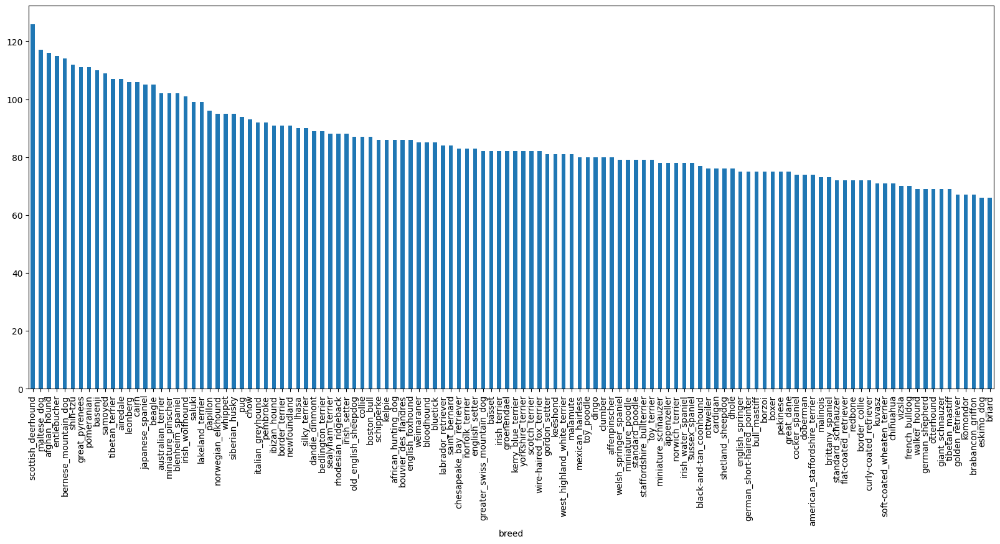

In [ ]:
# How many images are there of each breed?
labels_csv["breed"].value_counts().plot(kind="bar", figsize=(20, 8))

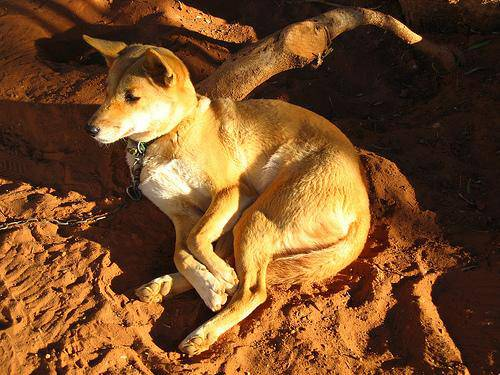

In [ ]:
# Let's view an image
from IPython.display import Image
Image("/content/drive/MyDrive/dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg")

### Getting images and their labels

Let's get a list of all of our image file pathnames.

In [ ]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [ ]:
# Create paathnames from image ID's
filenames = ["/content/drive/MyDrive/dog-breed-identification/train/"+fname + ".jpg" for fname in labels_csv["id"]]

# Check the first 10
filenames[:10]

['/content/drive/MyDrive/dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/002a283a315af96eaea0e28e7163b21b.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 '/content/drive/MyDrive/dog-breed-identification/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [ ]:
len(filenames)

10222

In [ ]:
import os
if len(os.listdir("/content/drive/MyDrive/dog-breed-identification/train")) == len(filenames):
  print("Filenames match actual amount of files!! Proceed.")
else:
  print("Filenames failed to match actual amount of files!!")

Filenames match actual amount of files!! Proceed.


In [ ]:
labels_csv["breed"][1500]

'boston_bull'

Since we've now got our training image filepaths in a list, let's prepare our labels.

In [ ]:
import numpy as np
labels = labels_csv["breed"].to_numpy()
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [ ]:
# See if number of labels matches the number of filenames
if len(labels) == len(filenames):
  print("Number of labels matches number of filenames")
else:
  print("Number of labels does not match number of filenames")

Number of labels matches number of filenames


In [ ]:
# Find the unique label values
unique_breeds = np.unique(labels)
unique_breeds, len(unique_breeds)

(array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
        'american_staffordshire_terrier', 'appenzeller',
        'australian_terrier', 'basenji', 'basset', 'beagle',
        'bedlington_terrier', 'bernese_mountain_dog',
        'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
        'bluetick', 'border_collie', 'border_terrier', 'borzoi',
        'boston_bull', 'bouvier_des_flandres', 'boxer',
        'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
        'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
        'chow', 'clumber', 'cocker_spaniel', 'collie',
        'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
        'doberman', 'english_foxhound', 'english_setter',
        'english_springer', 'entlebucher', 'eskimo_dog',
        'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
        'german_short-haired_pointer', 'giant_schnauzer',
        'golden_retriever', 'gordon_setter', 'gre

In [ ]:
# Turn ebery label into a boolean array
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:1]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False])]

In [ ]:
len(boolean_labels)

10222

In [ ]:
# Example: Turning Boolean array into integers
print(labels[0]) # original label
print(np.where(unique_breeds == labels[0])) # index where label occurs
print(boolean_labels[0].argmax()) # index where label occurs in boolean array
print(boolean_labels[0].astype(int)) # there will be a 1 where the sample label occurs

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [ ]:
print(labels[2])
print(boolean_labels[2].astype(int))

pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


### Creating our own validation set

Since the data in kaggle datasets doesn't  come with a validation set, we're going to create our own.

In [ ]:
# Setup X & y variables
X = filenames
y = boolean_labels


We're going to start off experimenting with ~1000 images and increase as needed.

In [ ]:
# Set number of images to use for experimenting
NUM_IMAGES = 1700 #@param {type:"slider", min:1000, max:10000, step:100 }

In [ ]:
# Let's split our data into train and validation sets
from sklearn.model_selection import train_test_split

# Split them into training and validation of total size NUM_IMAGES
X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  test_size=0.2,
                                                  random_state=42)
len(X_train), len(y_train), len(X_val), len(y_val)

(1360, 1360, 340, 340)

In [ ]:
# Let's have a geez at the training data
X_train[:3], y_train[:3]

(['/content/drive/MyDrive/dog-breed-identification/train/21dfcac3b5cc302372a081c0bdc7a24c.jpg',
  '/content/drive/MyDrive/dog-breed-identification/train/20be3ce1dd7db9194c856726c2f154a3.jpg',
  '/content/drive/MyDrive/dog-breed-identification/train/1d75b0cf9ad1bd98e84bb5d0d4d3ac0f.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False

## Preprocessing Images (Turning images into tensors)

To preprocess our images into Tensors we're going to write a function which does a few things:
1. Take an image filepath as input
2. Use TensorFlow to read the file and save it to a variable, `image`
3. Turn our `image` (a jpg) into Tensors
4. Resize the `image` to be a shape of (224, 224)
5. Return the modified `image`

In [ ]:
# Convert image to NumPy
from matplotlib.pyplot import imread
image = imread(filenames[42])
image.shape

(257, 350, 3)

In [ ]:
image.max(), image.min()

(np.uint8(255), np.uint8(0))

In [ ]:
image[:2]

array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)

In [ ]:
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)>

### Now we've seen what an image looks like as a Tensor, let's make a function to preprocess them.

 1. Take an image filepath as input
 2. Use TensorFlow to read the file and save it to a variable, `image`
 3. Turn our `image` (a jpg) into Tensors
 4. Normalize our `image` (convert color channel values from 0-255 to 0-1.
 5. Resize the `image` to be a shape of (224, 224)
 6. Return the modified `image`

In [ ]:
# DEfine image size
IMG_SIZE = 224

# Create a function for preprocessing
def process_image(image_path, img_size=IMG_SIZE):
  """
  Takes an image filepath and turns the image into a Tensor
  """
  # Read in an image file
  image = tf.io.read_file(image_path)
  # Turn the jpeg image into numerical Tensor with 3 color channels (RGB)
  image = tf.image.decode_jpeg(image, channels = 3)
  # Convert the color channek  values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)
  # Resize the image to our desired value (224, 224)
  image = tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])

  return image

In [ ]:
teensor = tf.io.read_file(filenames[4])
teensor

<tf.Tensor: shape=(), dtype=string, numpy=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\n\x07\x07\x08\x07\x06\n\x08\x08\x08\x0b\n\n\x0b\x0e\x18\x10\x0e\r\r\x0e\x1d\x15\x16\x11\x18#\x1f%$"\x1f"!&+7/&)4)!"0A149;>>>%.DIC<H7=>;\xff\xdb\x00C\x01\n\x0b\x0b\x0e\r\x0e\x1c\x10\x10\x1c;("(;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;\xff\xc0\x00\x11\x08\x01\xf4\x01\xf4\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\

In [ ]:
tensor = tf.image.decode_jpeg(teensor, channels=3)
tf.image.convert_image_dtype(tensor, tf.float32)

<tf.Tensor: shape=(500, 500, 3), dtype=float32, numpy=
array([[[0.32156864, 0.34117648, 0.31764707],
        [0.32156864, 0.34117648, 0.31764707],
        [0.32156864, 0.34117648, 0.31764707],
        ...,
        [0.29411766, 0.33333334, 0.3019608 ],
        [0.29411766, 0.33333334, 0.3019608 ],
        [0.29411766, 0.33333334, 0.3019608 ]],

       [[0.3137255 , 0.33333334, 0.30980393],
        [0.3137255 , 0.33333334, 0.30980393],
        [0.3137255 , 0.33333334, 0.30980393],
        ...,
        [0.29411766, 0.33333334, 0.3019608 ],
        [0.29411766, 0.33333334, 0.3019608 ],
        [0.29411766, 0.33333334, 0.3019608 ]],

       [[0.30588236, 0.3254902 , 0.3019608 ],
        [0.30588236, 0.3254902 , 0.3019608 ],
        [0.30588236, 0.3254902 , 0.3019608 ],
        ...,
        [0.3019608 , 0.32941177, 0.3019608 ],
        [0.3019608 , 0.32941177, 0.3019608 ],
        [0.3019608 , 0.32941177, 0.3019608 ]],

       ...,

       [[0.3529412 , 0.37254903, 0.34901962],
        [0.33

## Turning our data into batches

Why turn our data into batches?

Let's say you're trying to process 10,000+ images in one go... they all might not fit into memory.

So that's why we do about 32 (this is the batch size) images at a time (you can manually adjust batch size if need be).

In order to use TensorFlow effectively, we need our data in the form of Tensor tuples which look like this:
`(image, label)`

In [ ]:
# Create a simple function to return a tuple (image, label)

def get_image_label(image_path, label):
  """
  Take an image file path name and the associated label,
  process the image and returns a tuple of (image, label).
  """
  image = process_image(image_path)
  return image, label

In [ ]:
process_image(X[4], tf.constant(y[4]))

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.3167367 , 0.33634454, 0.31281513],
        [0.3167367 , 0.33634454, 0.31281513],
        [0.3167367 , 0.33634454, 0.31281513],
        ...,
        [0.33333334, 0.3372549 , 0.31764707],
        [0.30077025, 0.33000705, 0.3019608 ],
        [0.29411766, 0.33333334, 0.3019608 ]],

       [[0.2992297 , 0.31883755, 0.29530814],
        [0.2992297 , 0.31883755, 0.29530814],
        [0.2992297 , 0.31883755, 0.29530814],
        ...,
        [0.33333334, 0.3372549 , 0.31764707],
        [0.3052871 , 0.32608548, 0.3019608 ],
        [0.3019608 , 0.32941177, 0.3019608 ]],

       [[0.30227593, 0.32188377, 0.29835436],
        [0.30227593, 0.32188377, 0.29835436],
        [0.30227593, 0.32188377, 0.29835436],
        ...,
        [0.33333334, 0.3372549 , 0.31764707],
        [0.30533493, 0.32603765, 0.3019608 ],
        [0.30227593, 0.32909665, 0.3019608 ]],

       ...,

       [[0.53057134, 0.5344929 , 0.51488507],
        [0.27

Now we've got a way turn our data into tuples of Tensors in the form: `(image, label)`, let's make a function to turn all of our data (x & y) into batches!

In [ ]:
# Define the batch size, 32 is a good start
BATCH_SIZE = 32

# Create a function to turn data into batches
def create_data_batches(X, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
  """
  Creates batches of data out of image (X) and label (y) pairs.
  Shuffles the data if it's training data but doesn't shuffle it if it's validation data.
  Also accepts test data as input (no labels).
  """
  # If the data is a test dataset, we probably don't have labels
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices(tf.constant(X)) # only filepaths (no labels)
    data_batch = data.map(process_image).batch(BATCH_SIZE)
    return data_batch

  # If the data is a valid dataset, we don't need to shuffle it
  elif valid_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),  # filepaths
                                              tf.constant(y))) # labels
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch

  else:
    print("Creating training data batches...")
    # Turn filepaths and labels into Tensors
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),
                                              tf.constant(y)))
    # Shuffling pathnames and labels before mapping image processor function is faster than shuffling images
    data = data.shuffle(buffer_size=len(X))

    #Create (image, label) tuples (this alsi turns the image path into a preprocessed image)
    data = data.map(get_image_label)

    # Turn the training data into batches
    data_batch = data.batch(BATCH_SIZE)
  return data_batch


In [ ]:
# Create training and validation data batches
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val, y_val, valid_data=True)

Creating training data batches...
Creating validation data batches...


In [ ]:
# Check out the different atributes of our data batches
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

In [ ]:
print(train_data.element_spec)
print(val_data.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))


## Visualizing Data BAtches

Our data is now in batches, however, these can be a  little hard to understand/comprehend, let's visualize them

In [ ]:
import matplotlib.pyplot as plt
# Create a function for viewing images in a data batch
def show_25_images(images, labels):
  """
  Displays a plot of 25 images and their labels form a data batch.
  """

  # Setup the figure
  plt.figure(figsize=(15, 17))
  # Loop through 25(for displaying 25 images)
  for i in range(25):
    # Create subplots (5 rows, 5 columns)
    ax = plt.subplot(5, 5, i+1)
    # Display an image
    plt.imshow(images[i])
    # Add the image label as the title
    plt.title(unique_breeds[labels[i].argmax()])
    # Turn the grid lines off
    plt.axis("off")

In [ ]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

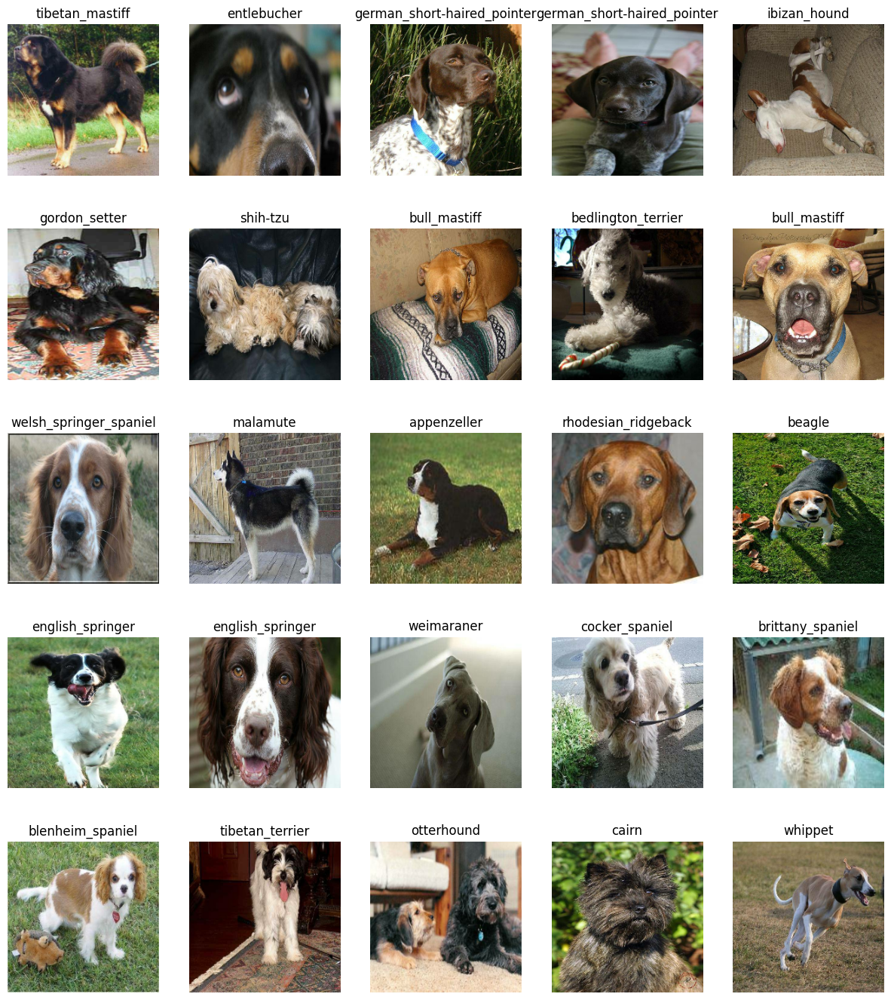

In [ ]:

# Now let's visualise the data in a training batch
train_images, train_labels = next(train_data.as_numpy_iterator())
show_25_images(train_images, train_labels)

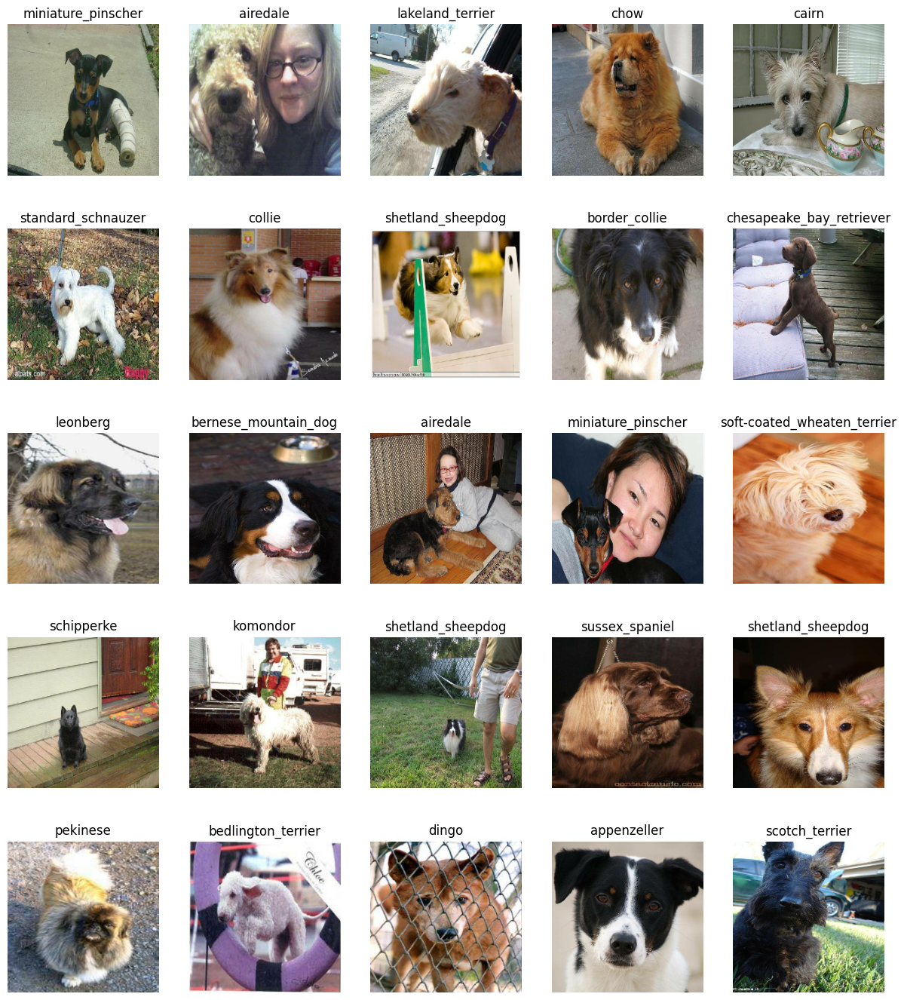

In [ ]:
# Now let's visualize our validation set
val_images, val_labels = next(val_data.as_numpy_iterator())
show_25_images(val_images, val_labels)

## Building a model

Before we build a model, there are a few things we need to define:
  * The input shape (our images shape, in the form of Tensors) to our model.
  * The output shape (image labels, in the form of Tensors) of our model.
  * The URL of the model we want to use.

In [ ]:
# Setup  input shape to the model
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3]  #batch, height, width, color channels

# Setup output shape to the model
OUTPUT_SHAPE = len(unique_breeds)

# Setup model URL from TensorFlow Hub
MODEL_URL = "https://tfhub.dev/google/imagenet/mobilenet_v2_035_128/classification/5"

Now we've got our inputs, outputs and model ready to go.
Let's put them together into a keras deep learning model!

Knowing this, let's create a function which:
* Takes the input shape, output shape and the model we've chosen as parameters.
* Defines the layers in a Keras model in sequential fashion (do this first, then this, then that).
* Compiles the model (says it should be evaluated and improved).
* Builds the model (tells the model the input shape it'll be getting).
* Returns the model.

All of these steps can be found here: https://www.tensorflow.org/guide/keras/overview

In [ ]:
# Create a function which builds a keras model
def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
  print("Building model with: ", MODEL_URL)

  # SEtup the model ;ayers
  model = tf.keras.Sequential([
      tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                        include_top=False,
                                        weights="imagenet"), # Layer 1 (input layer)
      tf.keras.layers.GlobalAveragePooling2D(),
      tf.keras.layers.Dense(units=OUTPUT_SHAPE,
                             activation="softmax")  # Layer 2 (Output layer)

  ])

  # Compile the model
  model.compile(
      loss=tf.keras.losses.CategoricalCrossentropy(),
      optimizer=tf.keras.optimizers.Adam(),
      metrics=["accuracy"]
  )

  # Build the model
  model.build(INPUT_SHAPE)

  return model

In [ ]:
model = create_model()
model.summary()

Building model with:  https://tfhub.dev/google/imagenet/mobilenet_v2_035_128/classification/5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,411,704 (9.20 MB)

 Trainable params: 2,377,592 (9.07 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
outputs = np.ones(shape=(1, 1, 1280))
outputs

array([[[1., 1., 1., ..., 1., 1., 1.]]])

## Creating Callbacks

Callbacks are helper functions a model can use duirng training to do such things as save its progress  or stop training early if a model stops improving.

We'll create two callbacks, one for TensorBoard which helps track our models progress and annother for early stopping which prevents our model from training for too long.

## TensorFlow Callback

To setup a TensorBoard callback, we need to do 3 things:
  1. Load the Tensorboard notebook extension
  2. Create a tensoboard callback which is abl to save logs to a directory and pass it to our model's fit() function.
  3. Visualize our model training logs with the `%tennsorboard` magic function (we'll do this after model training).

In [ ]:
# Load TensorBoard notebook extension
%load_ext tensorboard

In [ ]:
import datetime

# Create a function to build a TensorBoard ccallback
def create_tensorboard_callback():
  # Create a log directory for storing TensorBoard logs
  logdir = os.path.join("drive/MyDrive/dog-breed-identification/logs",
                        # Make it so the logs get tracked whenever we run an experiment
                        datetime.datetime.now().strftime("%Ym%d-%H%M%S"))

  return tf.keras.callbacks.TensorBoard(logdir)


### Early Stopping Callback

Early stopping helps stop our model from overfitting by stopping training if a certain evaluation metric stops improving.

https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping

In [ ]:
# Create early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                  patience=3)

#3 Training a model (on subset of data)

Our first model is going to train on 1000 images, to make sure everything is working.


In [ ]:
NUM_EPOCHS = 100 #@param {type:"slider", min:0, max:100, step:10}

In [ ]:
print("GPU", "available" if tf.config.list_physical_devices("GPU") else "Not available")

GPU available


Let's create  a function that trains the  model

* Create a model using `create_model()`
* Setup a TensorBoard callback using `create_tensorboard_callback()`
* Call the `fit()` funcction on our model passing it the training data, validation data, number of epochs to train for `(NUM_EPOCHS)` and the callbacks we'd like to use
* Return the model

In [ ]:
#  build a function to train and return a  trained model
def train_model():
  """
  Trains a given model and returns the trained version.
  """
  # Create a model
  model =  create_model()

  # Create nnew tennsorboard session everytime we trainn a model
  tensorboard = create_tensorboard_callback()

  # Fit the model to the data passing it the callbacks we created
  model.fit(x=train_data,
            epochs=NUM_EPOCHS,
            validation_freq=1,
            callbacks=[tensorboard, early_stopping])

  # Return the fitted model
  return model

In [ ]:
 # Fit the model to the data
 model = train_model()

Building model with:  https://tfhub.dev/google/imagenet/mobilenet_v2_035_128/classification/5
Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 114s 937ms/step - accuracy: 0.1993 - loss: 3.6916
Epoch 2/100


/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.5397 - loss: 1.6814
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.7750 - loss: 0.8295
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.9147 - loss: 0.3279
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9596 - loss: 0.1915
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9801 - loss: 0.0995
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9838 - loss: 0.0720
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9750 - loss: 0.1046
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.9787 - loss: 0.0953
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9713 - loss: 0.1083
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9706 - loss: 0.1165
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9162 - loss: 0.3018
Epoch 13/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step

## Checking the Tensorboard logs

The TensorBoard magic function (%tensorboard) will access the logs directory we created earlier and visualize its contents.

In [ ]:
%tensorboard --logdir drive/My\Drive/dog-breed-identification/logs

<IPython.core.display.Javascript object>

## Making and evaluating predictions using a trained model

In [ ]:
# Make preedictions on the validation data (nooot used to train on)
predictions = model.predict(val_data, verbose=1)
predictions

11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


array([[1.94581773e-07, 2.18425171e-07, 1.01654511e-10, ...,
        2.54403859e-10, 1.17238487e-05, 1.76231012e-01],
       [2.84450853e-05, 9.79630613e-07, 2.40837238e-07, ...,
        3.16425769e-07, 5.17073095e-05, 5.88088151e-05],
       [8.12880788e-03, 3.66828062e-05, 3.37210215e-09, ...,
        9.33341404e-09, 7.58006354e-05, 6.77027330e-02],
       ...,
       [9.02460888e-04, 1.61550601e-03, 3.19682725e-10, ...,
        5.28992643e-07, 2.13253697e-05, 3.70314978e-02],
       [1.19279662e-06, 3.83596853e-06, 3.95062108e-11, ...,
        1.08682094e-07, 1.42713208e-04, 2.18384210e-02],
       [3.74666834e-03, 2.57281732e-04, 2.68866052e-06, ...,
        9.61793739e-06, 4.69159894e-03, 1.77628882e-02]], dtype=float32)

In [ ]:
predictions.shape

(340, 120)

In [ ]:
len(y_val)

340

In [ ]:
predictions[0]

array([1.94581773e-07, 2.18425171e-07, 1.01654511e-10, 6.01815131e-09,
       5.70639827e-07, 9.15557575e-06, 7.60309078e-08, 1.28161733e-03,
       4.40890206e-11, 6.42338138e-09, 2.68414739e-13, 1.56328625e-07,
       1.35173517e-09, 3.62518449e-07, 2.90809016e-13, 1.34129596e-08,
       1.41208739e-06, 3.01563596e-09, 4.36925496e-11, 1.53490240e-04,
       2.09676738e-11, 4.84367060e-12, 6.40133946e-10, 5.79727137e-15,
       1.21773869e-10, 2.57956989e-11, 7.27022565e-12, 6.46408535e-06,
       6.07779826e-10, 1.86791249e-10, 2.90877278e-09, 3.28635963e-13,
       2.42871863e-07, 3.87353830e-05, 1.98183882e-11, 1.14807003e-12,
       1.13699426e-14, 1.44885980e-12, 2.37009541e-08, 6.78557557e-11,
       2.49629500e-13, 6.75536711e-08, 1.70580723e-08, 1.60969940e-08,
       6.11489678e-12, 7.69731015e-11, 8.52366533e-09, 6.08643465e-16,
       5.77744406e-12, 1.17462561e-12, 4.30612941e-11, 6.06207012e-12,
       9.18423737e-09, 3.68594119e-05, 2.60682257e-11, 3.44551929e-14,
      

In [ ]:
np.sum(predictions[12])

np.float32(0.99999994)

In [ ]:
# First prediction
index=42
print(predictions[index])
print(f"Max value (probability of prediction): {np.max(predictions[index])}")
print(f"Sum of predictions: {np.sum(predictions[index])}")
print(f"Max index: {np.argmax(predictions[index])}")
print(f"Predicted label: {unique_breeds[np.argmax(predictions[index])]}")

[5.19700602e-11 1.61923413e-06 2.95867664e-10 6.35844572e-07
 1.50238884e-06 1.19006954e-01 3.41937878e-09 5.71583005e-05
 6.73400624e-09 5.91878745e-07 2.21132626e-11 1.15522307e-04
 1.42713390e-07 1.72954083e-06 2.15525180e-08 1.49889849e-03
 5.77160222e-07 1.95193006e-05 6.75035153e-07 1.74873520e-08
 1.56392520e-11 1.76931809e-12 1.36417046e-04 2.15734219e-11
 3.82506954e-07 1.14577549e-11 8.39222380e-08 2.85436414e-07
 2.62727241e-07 7.32029493e-10 2.76321299e-10 3.13217247e-12
 3.69421315e-07 3.61862738e-04 5.01857667e-10 2.30872460e-10
 5.78573717e-11 1.80056059e-08 1.54553936e-06 2.97693106e-07
 2.38277238e-08 2.61440931e-08 8.71099770e-01 2.26116761e-08
 6.43447038e-07 2.49998671e-13 1.10769588e-06 6.57730759e-10
 4.23309388e-09 3.26969674e-09 1.23311366e-07 5.05319788e-12
 1.59458775e-08 6.20802632e-04 4.92428320e-08 8.65389878e-12
 9.91471141e-11 6.96076938e-08 5.83663534e-11 6.23146423e-10
 3.17192250e-09 1.63475089e-09 1.68114478e-09 2.39577531e-07
 1.08088982e-09 7.847521

In [ ]:
# Turn prediction probabilities into their respective labels (easier to understand)
def get_pred_label(prediction_probabilities):
  """
  Turns an array of prediction probabilities into a label.
  """

  return unique_breeds[np.argmax(prediction_probabilities)]

# Get a predicted label based on an array of prediction probabilities
pred_label = get_pred_label(predictions[4])
pred_label

'yorkshire_terrier'

Now since our validation set is still in a batch dataset, we'll have to unbatchify it to make predictions on the validatio images and then compare those predictions to the validation labels (truth labels).

In [ ]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [ ]:
images_ = []
labels_ = []

# Loop through unbatched data
for image, label in val_data.unbatch().as_numpy_iterator():
  images_.append(image)
  labels_.append(label)

images_[1], labels_[1]

(array([[[0.8668068 , 0.9295519 , 0.98669475],
         [0.8668068 , 0.9320729 , 0.9753102 ],
         [0.8668068 , 0.9337536 , 0.959804  ],
         ...,
         [0.82088906, 0.9556226 , 0.95170105],
         [0.8283914 , 0.9589236 , 0.955002  ],
         [0.8082329 , 0.9337231 , 0.9298015 ]],
 
        [[0.87100846, 0.9338436 , 0.9900561 ],
         [0.87100846, 0.9364246 , 0.9743498 ],
         [0.87100846, 0.93834543, 0.96322536],
         ...,
         [0.81689733, 0.95163083, 0.94770926],
         [0.82256913, 0.9531013 , 0.9491797 ],
         [0.8121046 , 0.9375948 , 0.9336732 ]],
 
        [[0.87521017, 0.93934584, 0.9858544 ],
         [0.87521017, 0.9418768 , 0.9751001 ],
         [0.87521017, 0.9457984 , 0.96092445],
         ...,
         [0.81004435, 0.94477785, 0.9408563 ],
         [0.81366557, 0.9441978 , 0.9402762 ],
         [0.8201581 , 0.9456483 , 0.94172674]],
 
        ...,
 
        [[0.3915867 , 0.4660965 , 0.44256708],
         [0.4609444 , 0.52789116, 0.51192

In [ ]:
def unbatchify(data):
  """
  Takes a batched dataset of (image, label) Tensors and returns seperate arrays of images and labels.
  """

  images = []
  labels = []

  for image, label in data.unbatch().as_numpy_iterator():
    images.append(image)
    labels.append(unique_breeds[np.argmax(label)])
  return images, labels

val_images, val_labels = unbatchify(val_data)
val_images[0], val_labels[0]

(array([[[0.61559874, 0.55840385, 0.48389405],
         [0.6261292 , 0.569548  , 0.4950382 ],
         [0.61812097, 0.56172854, 0.48721874],
         ...,
         [0.39222258, 0.42359513, 0.23928142],
         [0.32389173, 0.34742114, 0.167029  ],
         [0.3739164 , 0.3974458 , 0.21705362]],
 
        [[0.59873   , 0.55274653, 0.4757602 ],
         [0.6228162 , 0.57863307, 0.5007465 ],
         [0.62303925, 0.5794101 , 0.5012465 ],
         ...,
         [0.29791504, 0.3292876 , 0.13776095],
         [0.23601344, 0.25764567, 0.07915068],
         [0.22235899, 0.23412369, 0.06549622]],
 
        [[0.62807775, 0.6020798 , 0.51703954],
         [0.60511374, 0.57911587, 0.49407563],
         [0.60548854, 0.57949066, 0.4944504 ],
         ...,
         [0.513244  , 0.5446165 , 0.35265803],
         [0.4041663 , 0.41552308, 0.24811938],
         [0.3599352 , 0.3690126 , 0.20844708]],
 
        ...,
 
        [[0.15171368, 0.1870078 , 0.1752431 ],
         [0.2097611 , 0.24505521, 0.23329

Now we've got ways to get:
   * Prediction labels
   * Validation labels (truth labels)
   * Validation images

Let's make some function to make these all a bit more visualize.

We'll create a function which:
* Takes an array of prediction probabilities, an array of tuth labels and an array of images and integers.
* Convert the prediction probabilities to a predicted label.
* Plot the predicted label, its predicted probability, the truth label and the target image in a single plot.

In [ ]:
def plot_pred(prediction_probabilities, labels, images, n=1):
  """
  View the prediction, ground truth, and image for sample n
  """
  pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]

  # Get the pred label
  pred_label = get_pred_label(pred_prob)

  # Plot image & remove ticks
  plt.imshow(image)
  plt.xticks([])
  plt.yticks([])

  # CHange plot title to be predicted, probability of predictiob and truth label
  plt.title("{} {:2.0f}% {}".format(pred_label,
                                    np.max(pred_prob)*100,
                                    true_label))

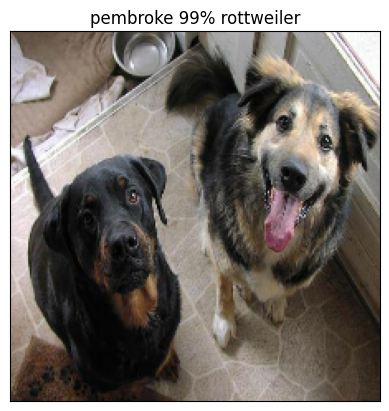

In [ ]:
plot_pred(prediction_probabilities=predictions,
          labels=val_labels,
          images=val_images,
          n=77)

from inspect import indentsize
Now we've got one function to visualize our models top prediction, let's make another to view our top 3 predictions.

This function will:
* Take an input of prediction probabilities array and a ground truth array and an np.integer
* Find the prediction using `get_pred_label()`
* Find the top 10:
    * Prediction probabilities indices
    * Predicition probabilities values
    * Prediction labels
* Plot the top 10 prediction probability values and labels, coloring the true label green

In [ ]:
def plot_pred_conf(prediction_probabilities, labels, n=1):  # n = index of sample to plot
  """
  Plot the top 10 highest prediction confidences along with the truth label for sample n.
  """
  pred_prob, true_label = prediction_probabilities[n], labels[n]

  # Get the predicted label
  pred_label = get_pred_label(pred_prob)

  # Find the top 10 prediction confidence indexes
  top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]
  # Find the top 10 prediction confidence values
  top_10_pred_values = pred_prob[top_10_pred_indexes]
  # Find the top 10 prediction labels
  top_10_pred_labels = unique_breeds[top_10_pred_indexes]
  # Setup plot
  top_plot = plt.bar(np.arange(len(top_10_pred_labels)),
                     top_10_pred_values,
                     color="grey")
  plt.xticks(np.arange(len(top_10_pred_labels)),
             labels=top_10_pred_labels,
             rotation="vertical")
  # Change color of true label
  if np.isin(true_label, top_10_pred_labels):
    top_plot[np.argmax(top_10_pred_labels == true_label)].set_color("green")
  else:
    pass

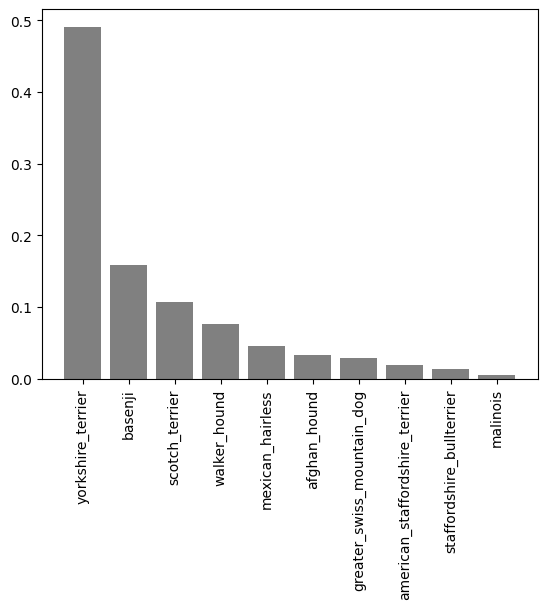

In [ ]:
plot_pred_conf(prediction_probabilities=predictions,
               labels=val_labels,
               n=9)

Now we've got some functions to help us visualize our predictions and evaluate our model, let's check out a few.

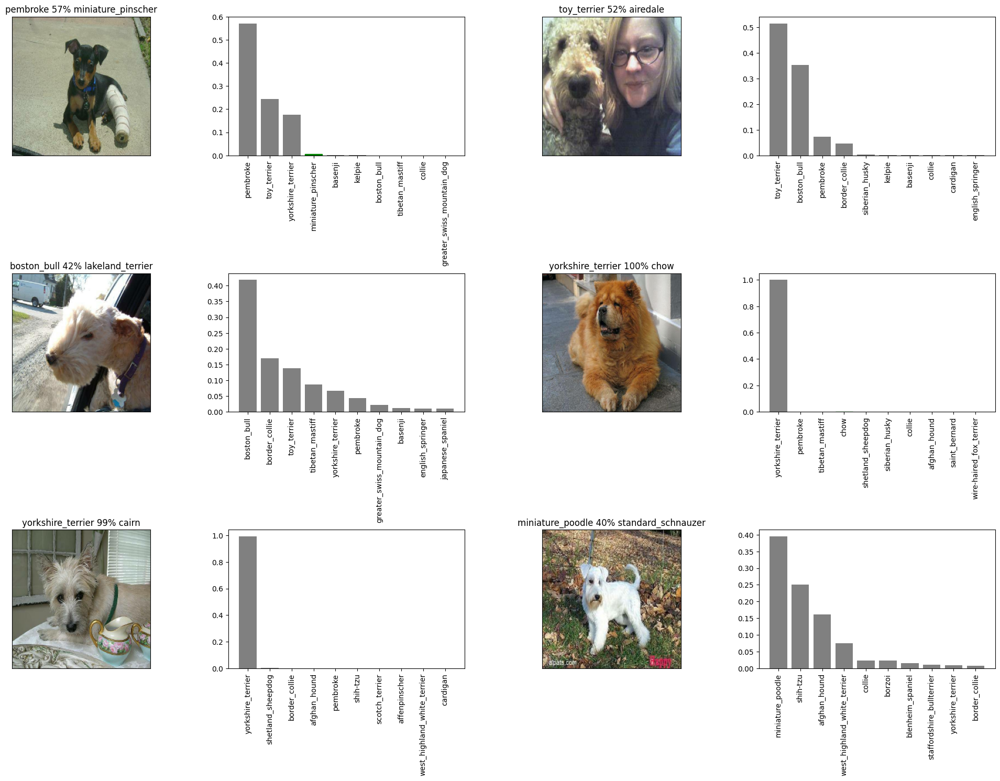

In [ ]:
# Let's check out a few predictions and their different values
i_multiplier = 0
num_rows = 3
num_cols=2
num_images = num_rows*num_cols
plt.figure(figsize=(10*num_cols, 5*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_pred(prediction_probabilities=predictions,
            labels=val_labels,
            images=val_images,
            n=i+i_multiplier)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_pred_conf(prediction_probabilities=predictions,
                 labels=val_labels,
                 n=i+i_multiplier)
plt.tight_layout(h_pad=1.0)
plt.show()


## Saving and reloading a trained model

In [ ]:
# Create a function to save a model
def save_model(model, suffix=None):
  """
  Saves a given model in model's directory and appends a suffix(string)
  """
  # Create a model directory pathname with current time
  modeldir = os.path.join("content/drive/MyDrive/dog-breed-identification/Models",
                          datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
  model_path = modeldir + "-" + suffix + ".h5" # save format of model
  print(f"Saving model to: {model_path}...")
  model.save(model_path)
  return model_path




In [ ]:
# Create a function to load a trained model
def load_model(model_path):
  """
  Loads a saved model from a given path.
  """
  print(f"Loading saved model from: {model_path}")
  model = tf.keras.models.load_model(model_path,
                                      custom_objects={"KerasLayer":hub.KerasLayer})
  return model

In [ ]:
# Save our model trained on 1000 images
save_model(model, suffix="000-images-mobilenetv2-SSHHSHSH")


Saving model to: content/drive/MyDrive/dog-breed-identification/Models/20260827-163852-000-images-mobilenetv2-SSHHSHSH.h5...


'content/drive/MyDrive/dog-breed-identification/Models/20260827-163852-000-images-mobilenetv2-SSHHSHSH.h5'

In [ ]:
# Loading trained model5
image_model = load_model("content/drive/MyDrive/dog-breed-identification/Models/20260827-163852-000-images-mobilenetv2-SSHHSHSH.h5")

Loading saved model from: content/drive/MyDrive/dog-breed-identification/Models/20260827-163852-000-images-mobilenetv2-SSHHSHSH.h5


In [ ]:
# Evaluate the pre-saved model
model.evaluate(val_data)

11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 536ms/step - accuracy: 0.0500 - loss: 11.0912


[11.09116268157959, 0.05000000074505806]

In [ ]:
# Evaluate the loaded model
image_model.evaluate(val_data)

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - accuracy: 0.0500 - loss: 11.0912


[11.09116268157959, 0.05000000074505806]

# Training model on full data

In [ ]:
# Create data batch with the full data set
full_data = create_data_batches(X, y)

Creating training data batches...


In [ ]:
full_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [ ]:
# Create a model for full model
full_model = create_model()

Building model with:  https://tfhub.dev/google/imagenet/mobilenet_v2_035_128/classification/5


In [ ]:
## Create full model callbacks
full_model_tensorboard = create_tensorboard_callback()
# No validation set when training on all the data, so we can't monitor validation accuracy
full_model_early_stopping = tf.keras.callbacks.EarlyStopping(monitor="accuracy", patience=3)

**Note:** RUnning the cell below will take a little while (maybe up to 30 minutes for the first epoch) because the GPU we're using in the runtime has to load all of the images into memory.

In [ ]:
# Fit the model to full data
full_model.fit(x=full_data,
               epochs=NUM_EPOCHS,
               callbacks=[full_model_tensorboard, full_model_early_stopping])

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 115s 223ms/step - accuracy: 0.3790 - loss: 2.3994
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.5484 - loss: 1.5275
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.6481 - loss: 1.1459
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.7088 - loss: 0.9387
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.7509 - loss: 0.7886
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.7988 - loss: 0.6287
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.8167 - loss: 0.5691
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8339 - loss: 0.5107
Epoch 9/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.8686 - loss: 0.4162
Epoch 10/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - accuracy: 0.8714 - loss: 0.4039
Epoch 11/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.8775 - loss: 0.3741
Epoch 1

In [ ]:
save_model(full_model, suffix="full-image-set")

Saving model to: content/drive/MyDrive/dog-breed-identification/Models/20260827-170250-full-image-set.h5...


'content/drive/MyDrive/dog-breed-identification/Models/20260827-170250-full-image-set.h5'

In [ ]:
# Load in the full model
loaded_full_model = load_model("content/drive/MyDrive/dog-breed-identification/Models/20260827-170250-full-image-set.h5")

Loading saved model from: content/drive/MyDrive/dog-breed-identification/Models/20260827-170250-full-image-set.h5


## Making predictions on the test dataset

Since our model has been trained on images in the form if Tensor batches , to make oredictions in the test data, we'll have to get it into the same format.

Luckily we created `create_data_batches()` earlier which can take a list of filenames as input and convert them into Tensor batches.

To make predictions on the test data, we'll:
* Get the test image filenames.
* Convert the filenames into test data batches using `create_data_batches()` and setting the `test_data` parameter to `True` (since the test data doesn't have labels).
* Make predictions array by passing the test batches to the `predict()` method called on our model.

In [ ]:
# Load test image filenames
test_path = "/content/drive/MyDrive/dog-breed-identification/test/"
test_filenames = [test_path + fname for fname in os.listdir(test_path)]
test_filenames[:5]

['/content/drive/MyDrive/dog-breed-identification/test/e967dd3dc67352cc2525c8283bf2751d.jpg',
 '/content/drive/MyDrive/dog-breed-identification/test/e78b50f1d12148deef4c564ea4c88050.jpg',
 '/content/drive/MyDrive/dog-breed-identification/test/ea1e945b924638c2059d7718b522d48f.jpg',
 '/content/drive/MyDrive/dog-breed-identification/test/e83f4c0ff6dec86d89d0f8b70ecd3cea.jpg',
 '/content/drive/MyDrive/dog-breed-identification/test/e9b105a5b7873f33477f777d5a9447f8.jpg']

In [ ]:
len(test_filenames)

10373

In [ ]:
# Create test data batch
test_data = create_data_batches(test_filenames, test_data=True)

Creating test data batches...


In [ ]:
test_data

<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

**Note:** Calling `predict()` on our full model and passing it the test data batch will take a long time to run (about an hour)

In [ ]:
# Make predictions on test data batch using the loaded full model
test_predictions = loaded_full_model.predict(test_data, verbose=1)

325/325 ━━━━━━━━━━━━━━━━━━━━ 275s 794ms/step


In [ ]:
!git status


fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!git clone https://github.com/vishky-3012/Dog-breed-classifier.git

Cloning into 'Dog-breed-classifier'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 257.12 KiB | 3.06 MiB/s, done.


In [ ]:
%cd Dog-breed-classifier


/content/Dog-breed-classifier


In [ ]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!ls /content/*.ipynb

ls: cannot access '/content/*.ipynb': No such file or directory


In [ ]:
!cp "/content/Dog-breed-classifier.ipynb" .

cp: cannot stat '/content/Dog-breed-classifier.ipynb': No such file or directory


In [ ]:
!find /content -name "*.ipynb"

/content/Dog-breed-classifier/Dog-breed-classifier.ipynb


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!pwd

/content/Dog-breed-classifier


In [ ]:
!ls -lh Dog-breed-classifier.ipynb

-rw-r--r-- 1 root root 461K Sep 30 04:59 Dog-breed-classifier.ipynb


In [ ]:
!git log -1 --oneline

3f58260 (HEAD -> main, origin/main, origin/HEAD) Add dog breed classifier notebook


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [2]:
!cp /content/Dog-breed-classifier.ipynb .

cp: cannot stat '/content/Dog-breed-classifier.ipynb': No such file or directory
